# 🧪 Week 2 Project

## Employee Performance & Compensation Analysis
**🎯 Business Scenario**

You're working as a Junior Data Analyst for a company.

The HR team wants to understand:

**Does higher salary correspond to better employee performance, and which departments have the strongest talent?**

Your job is to clean, analyze, visualize, and extract business insights from the employee dataset.

In [ ]:
import pandas as pd
import numpy as np

employees = pd.DataFrame({
    "employee_id": [101,102,103,104,105,106,107,108,109,110,111,112],
    "employee": ["A","B","C","D","E","F","G","H","I","J","K","L"],
    "department": [
        "IT","IT","IT",
        "HR","HR","HR",
        "Sales","Sales","Sales",
        "Finance","Finance","Finance"
    ],
    "experience": [2,7,5,3,6,9,4,8,2,10,7,5],
    "salary": [
        60000,90000,75000,
        50000,70000,np.nan,
        65000,85000,55000,
        120000,100000,90000
    ],
    "performance_score": [
        75,92,85,
        70,88,95,
        72,95,80,
        98,91,np.nan
    ]
})
employees

,employee_id,employee,department,experience,salary,performance_score
0,101,A,IT,2,60000.0,75.0
1,102,B,IT,7,90000.0,92.0
2,103,C,IT,5,75000.0,85.0
3,104,D,HR,3,50000.0,70.0
4,105,E,HR,6,70000.0,88.0
5,106,F,HR,9,NaN,95.0
6,107,G,Sales,4,65000.0,72.0
7,108,H,Sales,8,85000.0,95.0
8,109,I,Sales,2,55000.0,80.0
9,110,J,Finance,10,120000.0,98.0


## 1. Exploratory Data Analysis

In [ ]:
employees.shape

(12, 6)

In [ ]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        12 non-null     int64  
 1   employee           12 non-null     object 
 2   department         12 non-null     object 
 3   experience         12 non-null     int64  
 4   salary             11 non-null     float64
 5   performance_score  11 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 708.0+ bytes


In [ ]:
employees.isna().sum()

,0
employee_id,0
employee,0
department,0
experience,0
salary,1
performance_score,1


In [ ]:
employees.head()

,employee_id,employee,department,experience,salary,performance_score
0,101,A,IT,2,60000.0,75.0
1,102,B,IT,7,90000.0,92.0
2,103,C,IT,5,75000.0,85.0
3,104,D,HR,3,50000.0,70.0
4,105,E,HR,6,70000.0,88.0


In [ ]:
employees.describe(include='all')

,employee_id,employee,department,experience,salary,performance_score
count,12.000000,12,12,12.000000,11.000000,11.000000
unique,NaN,12,4,NaN,NaN,NaN
top,NaN,A,IT,NaN,NaN,NaN
freq,NaN,1,3,NaN,NaN,NaN
mean,106.500000,NaN,NaN,5.666667,78181.818182,85.545455
std,3.605551,NaN,NaN,2.640018,21127.319668,9.893065
min,101.000000,NaN,NaN,2.000000,50000.000000,70.000000
25%,103.750000,NaN,NaN,3.750000,62500.000000,77.500000
50%,106.500000,NaN,NaN,5.500000,75000.000000,88.000000
75%,109.250000,NaN,NaN,7.250000,90000.000000,93.500000


# 2. Data Cleaning

In [ ]:
employees

,employee_id,employee,department,experience,salary,performance_score
0,101,A,IT,2,60000.0,75.0
1,102,B,IT,7,90000.0,92.0
2,103,C,IT,5,75000.0,85.0
3,104,D,HR,3,50000.0,70.0
4,105,E,HR,6,70000.0,88.0
5,106,F,HR,9,NaN,95.0
6,107,G,Sales,4,65000.0,72.0
7,108,H,Sales,8,85000.0,95.0
8,109,I,Sales,2,55000.0,80.0
9,110,J,Finance,10,120000.0,98.0


In [ ]:
# replace the missing performance_score with mean.

employees['performance_score'] = employees['performance_score'].fillna(
    employees.groupby('department')['performance_score'].transform('mean')
    )


In [ ]:
employees

,employee_id,employee,department,experience,salary,performance_score
0,101,A,IT,2,60000.0,75.0
1,102,B,IT,7,90000.0,92.0
2,103,C,IT,5,75000.0,85.0
3,104,D,HR,3,50000.0,70.0
4,105,E,HR,6,70000.0,88.0
5,106,F,HR,9,NaN,95.0
6,107,G,Sales,4,65000.0,72.0
7,108,H,Sales,8,85000.0,95.0
8,109,I,Sales,2,55000.0,80.0
9,110,J,Finance,10,120000.0,98.0


In [ ]:
# Replace the salary with average dept salary.

employees['salary'] = employees['salary'].fillna(
    employees.groupby('department')['salary'].transform('mean')
    )

In [ ]:
employees

,employee_id,employee,department,experience,salary,performance_score
0,101,A,IT,2,60000.0,75.0
1,102,B,IT,7,90000.0,92.0
2,103,C,IT,5,75000.0,85.0
3,104,D,HR,3,50000.0,70.0
4,105,E,HR,6,70000.0,88.0
5,106,F,HR,9,60000.0,95.0
6,107,G,Sales,4,65000.0,72.0
7,108,H,Sales,8,85000.0,95.0
8,109,I,Sales,2,55000.0,80.0
9,110,J,Finance,10,120000.0,98.0


# 3. Descriptive Analysis

In [ ]:
# Overall
# Average salary
avg_salary = employees['salary'].mean()

# Median salary
median_salary = employees['salary'].median()

# Minimum salary
min_salary = employees['salary'].min()

# Maximum salary
max_salary = employees['salary'].max()

# Average performance score
avg_performance_score = employees['performance_score'].mean()

In [ ]:
avg_salary

np.float64(76666.66666666667)

In [ ]:
median_salary

72500.0

In [ ]:
min_salary

50000.0

In [ ]:
max_salary

120000.0

In [ ]:
avg_performance_score


np.float64(86.29166666666667)

In [ ]:
# By department

# Average salary
# Maximum salary
# Average performance
# Number of employees
employees.groupby('department').agg(
    average_salary = ('salary','mean'),
    maximun_salary = ('salary','max'),
    average_performance = ('performance_score','mean'),
    no_of_employees = ('employee_id','count')
).reset_index()

,department,average_salary,maximun_salary,average_performance,no_of_employees
0,Finance,103333.333333,120000.0,94.500000,3
1,HR,60000.000000,70000.0,84.333333,3
2,IT,75000.000000,90000.0,84.000000,3
3,Sales,68333.333333,85000.0,82.333333,3


# 4. Employee-Level Analysis

In [ ]:
# 1. Department average salary

employees['dept_avg_salary'] = employees.groupby('department')['salary'].transform('mean')

In [ ]:
# 2. Department average performance

employees['dept_avg_performance'] = employees.groupby('department')['performance_score'].transform('mean')

In [ ]:
# 3. Salary difference

employees['salary_difference'] = employees['salary'] - employees['dept_avg_salary']

In [ ]:
# 4. Performance category

categories = [
  employees['performance_score'] >= 90,
  employees['performance_score'] >= 80,
  employees['performance_score'] >= 70
]

choices = [
    'Excellent',
    'Good',
    'Average'
]
employees['performance_category'] = np.select(categories,choices,"Needs Improvement")

In [ ]:
employees

,employee_id,employee,department,experience,salary,performance_score,dept_avg_salary,dept_avg_performance,salary_difference,performance_category
0,101,A,IT,2,60000.0,75.0,75000.000000,84.000000,-15000.000000,Average
1,102,B,IT,7,90000.0,92.0,75000.000000,84.000000,15000.000000,Excellent
2,103,C,IT,5,75000.0,85.0,75000.000000,84.000000,0.000000,Good
3,104,D,HR,3,50000.0,70.0,60000.000000,84.333333,-10000.000000,Average
4,105,E,HR,6,70000.0,88.0,60000.000000,84.333333,10000.000000,Good
5,106,F,HR,9,60000.0,95.0,60000.000000,84.333333,0.000000,Excellent
6,107,G,Sales,4,65000.0,72.0,68333.333333,82.333333,-3333.333333,Average
7,108,H,Sales,8,85000.0,95.0,68333.333333,82.333333,16666.666667,Excellent
8,109,I,Sales,2,55000.0,80.0,68333.333333,82.333333,-13333.333333,Good
9,110,J,Finance,10,120000.0,98.0,103333.333333,94.500000,16666.666667,Excellent


# 5. Find High Performers

In [ ]:
# Finding high performers

high_performance_employees = employees.loc[
    (employees['salary'] > employees['dept_avg_salary']) &
    (employees['performance_score'] > employees['dept_avg_performance']),
    ['employee','department','salary','performance_score','salary_difference']
]
high_performance_employees

,employee,department,salary,performance_score,salary_difference
1,B,IT,90000.0,92.0,15000.000000
4,E,HR,70000.0,88.0,10000.000000
7,H,Sales,85000.0,95.0,16666.666667
9,J,Finance,120000.0,98.0,16666.666667


# 6. Visualization

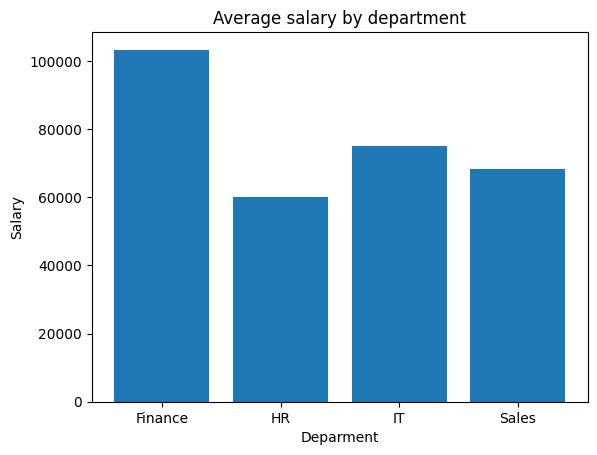

In [ ]:
# Average salary by department.

import matplotlib.pyplot as plt

plt.title("Average salary by department")
plt.xlabel('Deparment')
plt.ylabel("Salary")
plt.bar( employees.groupby('department')['salary'].mean().index,employees.groupby('department')['salary'].mean())
plt.show()

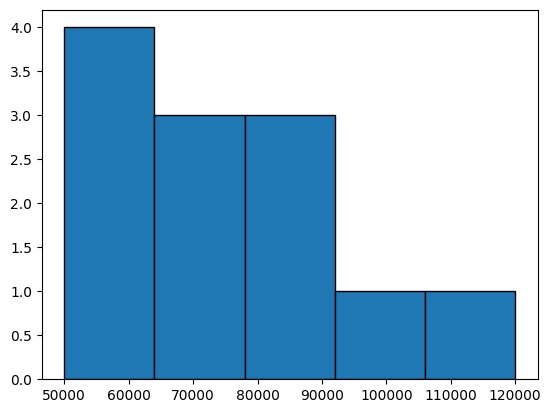

In [ ]:
# Salary distribution.

plt.hist(employees['salary'], bins=5, edgecolor='black')
plt.show()

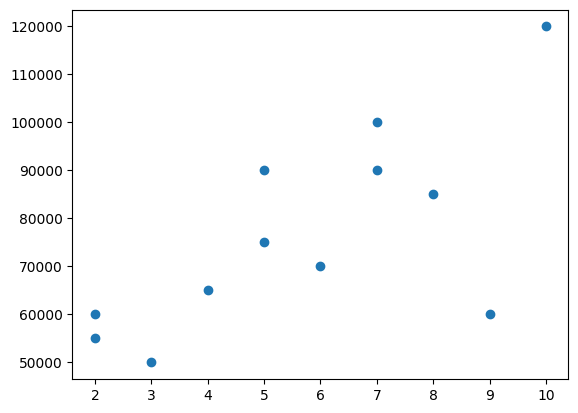

In [ ]:
# Experience vs Salary.

plt.scatter(employees['experience'], employees['salary'])
plt.show()

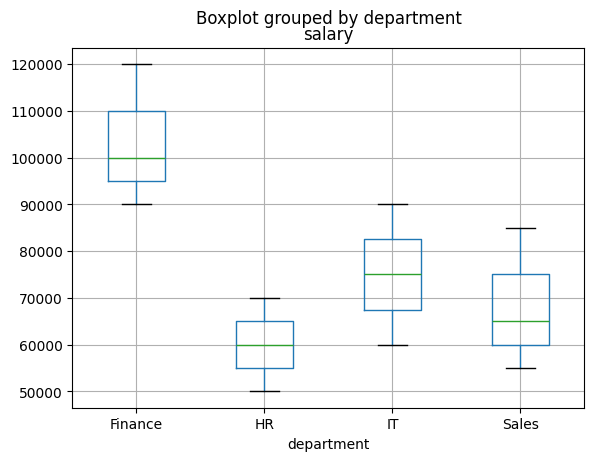

In [ ]:
# Salary distribution by department.

employees.boxplot(column='salary', by='department')
plt.show()

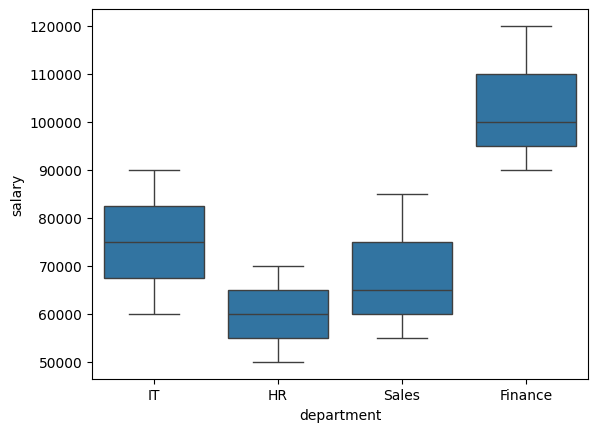

In [ ]:
import seaborn as sns
sns.boxplot(data=employees, x='department', y='salary')
plt.show()

# 7. Business Insights

## Business Insights

### 1. Which department has the highest average salary?

Finance has the highest average salary at approximately 103.3K, followed by IT, HR, and Sales.

### 2. Which department has the strongest average performance?

Finance has the highest average performance score at approximately 88.3, followed by HR, IT, and Sales.

### 3. Is there an apparent relationship between experience and salary?

There appears to be a positive relationship between experience and salary, as more experienced employees generally tend to earn higher salaries. However, the relationship is not perfectly consistent, since some highly experienced employees have relatively lower salaries.

### 4. Which employees are high performers relative to their department?

Employees **B (IT)**, **E (HR)**, **H (Sales)**, and **J (Finance)** are the high performers, as each has both an above-department-average salary and an above-department-average performance score.

### 5. Are there departments where employees have relatively high performance despite lower salaries?

Yes. HR and Sales have lower average salaries than Finance while still having relatively strong-performing employees. HR is particularly notable because it has an average performance of about 84.3 despite an average salary of about 68.3K.

### 6. What should HR potentially investigate?

HR should investigate whether compensation is appropriately aligned with performance, experience, and job responsibilities. In particular, they could review high-performing employees in lower-paid departments for potential compensation gaps or promotion opportunities. They should also examine relatively highly paid employees with weaker performance and determine whether differences are explained by seniority, role, or responsibilities.
